In [ ]:
!pip install tensorflow

# Mount colab with drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Set dataset paths

In [2]:
train_dir="/content/drive/MyDrive/Colab Notebooks/dense_brain/dataset/Training"
test_dir="/content/drive/MyDrive/Colab Notebooks/dense_brain/dataset/Testing"

### 3.Python Libraries Import

In [3]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten, Activation ,Dropout, GlobalAveragePooling2D,Input
from tensorflow.keras.optimizers import Adam
import os

### input size

In [4]:
img_size = (224, 224)
batch_size = 32

### Preprocess images of traning data

In [5]:
from tensorflow.keras.applications.densenet import preprocess_input
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,           # Increased
    width_shift_range=0.2,       # Increased
    height_shift_range=0.2,      # Increased
    shear_range=0.15,            # NEW - helps with overfitting
    zoom_range=0.2,              # Increased
    horizontal_flip=True,
    vertical_flip=True,          # NEW - medical images can be flipped vertically
    fill_mode='nearest',
    validation_split=0.2
)

### Testing data generator


In [6]:
from tensorflow.keras.applications.densenet import preprocess_input
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

### traning data generation

In [7]:
train_data=train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,  # by default it takes rgb colo image
    batch_size=32,
    color_mode='rgb',
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 4571 images belonging to 4 classes.


### Validation generator

In [8]:
valid_data=train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1141 images belonging to 4 classes.


### test data generation

In [9]:
test_data=test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
     shuffle=False

)

Found 1311 images belonging to 4 classes.


check imbelance

In [ ]:
print(train_data.class_indices)
print(train_data.classes)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
[0 0 0 ... 3 3 3]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.0811258278145695), 1: np.float64(1.0659981343283582), 2: np.float64(0.8955721003134797), 3: np.float64(0.9800600343053173)}


### load pretrain resnet50 model

In [ ]:
base_model=DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
# freeze  all layer of resnet base model
for layers in base_model.layers:
    layers.trainable=False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### freeze classification layers

In [ ]:
# Unfreeze last 20 layers (gradual unfreezing helps)
for layer in base_model.layers[-20:]:
    layer.trainable = True

# for layer in base_model.layers[-10:]:
 #    layer.trainable = True

### custom Classification model

In [ ]:
X_batch, y_batch = next(train_data)
print(X_batch)

[[[[-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   ...
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]]

  [[-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   ...
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]]

  [[-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   ...
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]]

  ...

  [[-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   ...
   [-2.1007793  -2.0182073  -1.7870152 ]
   [-2.1007793  -2.0182073  -1.7870152 ]
   [-2.1007793  

# CUSTOME LAYERS

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# Build simpler model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)  # Added L2 regularization
x = Dropout(0.6)(x)  # Increased dropout
x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)   # Smaller layer
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


# compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',      # my model is hot encoding formate [1 0 0 0]
    metrics=['accuracy']
)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,177,220 (27.38 MB)

 Trainable params: 506,884 (1.93 MB)

 Non-trainable params: 6,670,336 (25.45 MB)

call backs

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,           # Stop if no improvement for 10 epochs
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,            # Reduce learning rate by half
        patience=5,            # Wait 5 epochs before reducing
        min_lr=0.000001        # Minimum learning rate
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]

### train data

In [ ]:
'''
history=model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)
'''
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    validation_data=valid_data,
    validation_steps=len(valid_data),
    epochs=50,  # Increased epochs
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3468 - loss: 4.6126

143/143 ━━━━━━━━━━━━━━━━━━━━ 1435s 10s/step - accuracy: 0.3471 - loss: 4.6099 - val_accuracy: 0.5460 - val_loss: 3.6001 - learning_rate: 1.0000e-04
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5355 - loss: 3.4885

143/143 ━━━━━━━━━━━━━━━━━━━━ 1251s 8s/step - accuracy: 0.5357 - loss: 3.4875 - val_accuracy: 0.7020 - val_loss: 3.0029 - learning_rate: 1.0000e-04
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6460 - loss: 2.9362

143/143 ━━━━━━━━━━━━━━━━━━━━ 1209s 8s/step - accuracy: 0.6462 - loss: 2.9354 - val_accuracy: 0.7318 - val_loss: 2.5767 - learning_rate: 1.0000e-04
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7391 - loss: 2.5184

...

143/143 ━━━━━━━━━━━━━━━━━━━━ 1221s 8s/step - accuracy: 0.8453 - loss: 1.7632 - val_accuracy: 0.8221 - val_loss: 1.7391 - learning_rate: 1.0000e-04
Epoch 9/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8809 - loss: 1.6108

143/143 ━━━━━━━━━━━━━━━━━━━━ 1175s 8s/step - accuracy: 0.8809 - loss: 1.6108 - val_accuracy: 0.8466 - val_loss: 1.5871 - learning_rate: 1.0000e-04
Epoch 10/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8896 - loss: 1.5145

143/143 ━━━━━━━━━━━━━━━━━━━━ 1187s 8s/step - accuracy: 0.8896 - loss: 1.5144 - val_accuracy: 0.8659 - val_loss: 1.4927 - learning_rate: 1.0000e-04
Epoch 11/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8949 - loss: 1.4142

143/143 ━━━━━━━━━━━━━━━━━━━━ 1188s 8s/step - accuracy: 0.8949 - loss: 1.4141 - val_accuracy: 0.8826 - val_loss: 1.3936 - learning_rate: 1.0000e-04
Epoch 12/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1188s 8s/step - accuracy: 0.9104 - loss: 1.3119 - val_accuracy: 0.8773 - val_loss: 1.3335 - learning_rate: 1.0000e-04
Epoch 13/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9182 - loss: 1.2386

143/143 ━━━━━━━━━━━━━━━━━━━━ 1193s 8s/step - accuracy: 0.9181 - loss: 1.2386 - val_accuracy: 0.8913 - val_loss: 1.2640 - learning_rate: 1.0000e-04
Epoch 14/50
 13/143 ━━━━━━━━━━━━━━━━━━━━ 14:11 7s/step - accuracy: 0.9095 - loss: 1.2621

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("_model .h5", compile=False)

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    validation_data=valid_data,
    validation_steps=len(valid_data),
    epochs=50,          # FINAL epoch number
    initial_epoch=10,   # resume from epoch 11
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 11/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9093 - loss: 1.3148

143/143 ━━━━━━━━━━━━━━━━━━━━ 1093s 7s/step - accuracy: 0.9093 - loss: 1.3146 - val_accuracy: 0.8799 - val_loss: 1.3176 - learning_rate: 1.0000e-04
Epoch 12/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9190 - loss: 1.1892

143/143 ━━━━━━━━━━━━━━━━━━━━ 1008s 7s/step - accuracy: 0.9190 - loss: 1.1891 - val_accuracy: 0.8966 - val_loss: 1.1908 - learning_rate: 1.0000e-04
Epoch 13/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 983s 7s/step - accuracy: 0.9279 - loss: 1.1018 - val_accuracy: 0.8799 - val_loss: 1.1424 - learning_rate: 1.0000e-04
Epoch 14/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 972s 7s/step - accuracy: 0.9252 - loss: 1.0427 - val_accuracy: 0.8966 - val_loss: 1.0562 - learning_rate: 1.0000e-04
Epoch 15/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9376 - loss: 0.9720

143/143 ━━━━━━━━━━━━━━━━━━━━ 966s 7s/step - accuracy: 0.9376 - loss: 0.9719 - val_accuracy: 0.8992 - val_loss: 1.0250 - learning_rate: 1.0000e-04
Epoch 16/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 959s 7s/step - accuracy: 0.9372 - loss: 0.9278 - val_accuracy: 0.8948 - val_loss: 0.9672 - learning_rate: 1.0000e-04
Epoch 17/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9397 - loss: 0.8719

143/143 ━━━━━━━━━━━━━━━━━━━━ 981s 7s/step - accuracy: 0.9397 - loss: 0.8717 - val_accuracy: 0.9010 - val_loss: 0.9318 - learning_rate: 1.0000e-04
Epoch 18/50
 35/143 ━━━━━━━━━━━━━━━━━━━━ 9:41 5s/step - accuracy: 0.9425 - loss: 0.8149

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/model.h5", compile=False)

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    validation_data=valid_data,
    validation_steps=len(valid_data),
    epochs=50,          # FINAL epoch number
    initial_epoch=10,   # resume from epoch 11
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 11/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1915s 13s/step - accuracy: 0.9162 - loss: 1.2999 - val_accuracy: 0.8913 - val_loss: 1.2677 - learning_rate: 1.0000e-04
Epoch 12/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1029s 7s/step - accuracy: 0.9132 - loss: 1.1913 - val_accuracy: 0.8826 - val_loss: 1.2198 - learning_rate: 1.0000e-04
Epoch 13/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1030s 7s/step - accuracy: 0.9199 - loss: 1.1048 - val_accuracy: 0.8808 - val_loss: 1.1611 - learning_rate: 1.0000e-04
Epoch 14/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1034s 7s/step - accuracy: 0.9279 - loss: 1.0262 - val_accuracy: 0.8983 - val_loss: 1.0648 - learning_rate: 1.0000e-04
Epoch 15/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1035s 7s/step - accuracy: 0.9304 - loss: 0.9592 - val_accuracy: 0.9106 - val_loss: 0.9843 - learning_rate: 1.0000e-04
Epoch 16/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1047s 7s/step - accuracy: 0.9395 - loss: 0.8984 - val_accuracy: 0.8975 - val_loss: 0.9816 - learning_rate: 1.0000e-04
Epoch 17/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1016

In [11]:
from tensorflow.keras.models import load_model
model = load_model("/content/best_model.keras")

### model evalution

In [12]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 314s 8s/step - accuracy: 0.9073 - loss: 0.5149
Test Accuracy: 0.9374523162841797


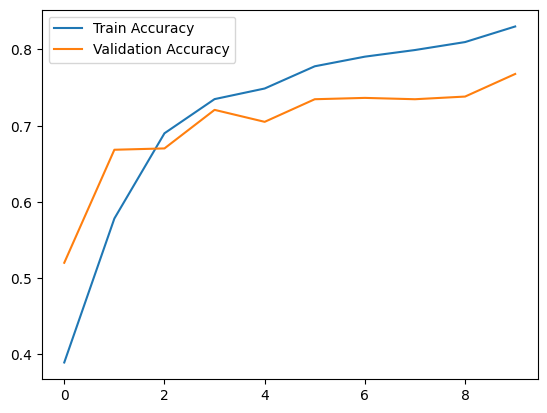

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


get true label and prediction

In [13]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Reset generator (VERY IMPORTANT)
test_data.reset()

# Predict probabilities
y_pred_probs = model.predict(test_data, verbose=1)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_data.classes

# Class names
class_names = list(test_data.class_indices.keys())



41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 266ms/step


visualization

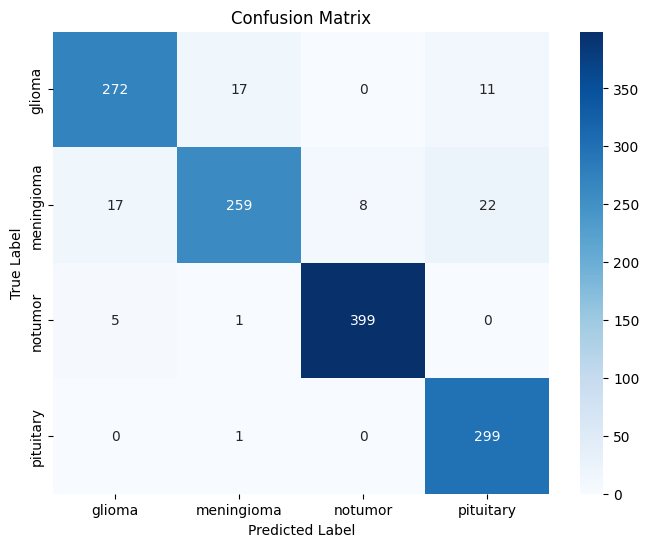

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


classification report

In [15]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

      glioma       0.93      0.91      0.92       300
  meningioma       0.93      0.85      0.89       306
     notumor       0.98      0.99      0.98       405
   pituitary       0.90      1.00      0.95       300

    accuracy                           0.94      1311
   macro avg       0.93      0.93      0.93      1311
weighted avg       0.94      0.94      0.94      1311



🔹 STEP 4: Resume training from correct epoch

👉 If you trained 10 epochs already, resume from epoch 10

In [16]:
from sklearn.metrics import confusion_matrix
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Row-wise normalization (per true class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


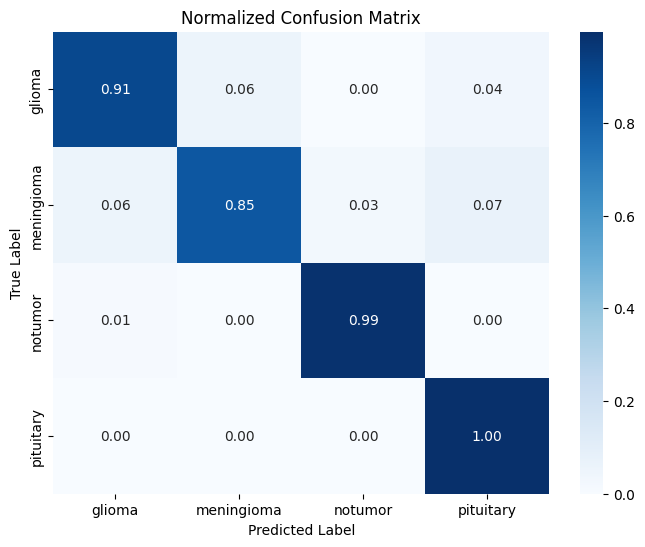

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()
